# Evaluación 4 - Modelo de Segmentación


**Integrante 1:** Paz Valdes  
**Integrante 2:** Maximiliano Matus  
**Integrante 3:** Santiago Franichevic


**Correo Electrónico Integrante 1:** paz.valdes2301@alumnos.ubiobio.cl  
**Correo Electrónico Integrante 2:** maximiliano.matus2301@alumnos.ubiobio.cl  
**Correo Electrónico Integrante 3:** santiago.franichevic2301@alumnos.ubiobio.cl


**Fecha de Creación:** Julio de 2026  
**Versión:** 1.0


---


## Descripción

Este notebook contiene el desarrollo de la Evaluación 4 de la asignatura **Inteligencia Artificial**
de la carrera de Ingeniería Civil en Informática de la Universidad del Bío-Bío, sede Concepción.

El objetivo es construir **dos modelos de segmentación independientes** sobre un dataset de clientes
de comercio electrónico, cada uno enfocado en una dimensión diferente del comportamiento del cliente.


## Requisitos de Software

Este notebook fue desarrollado con Python 3.11. A continuación se listan las bibliotecas necesarias:

- `pandas` (>=1.1.0)
- `numpy` (>=1.26.4)
- `matplotlib` (>=3.7.1)
- `seaborn` (>=0.13.1)
- `scikit-learn` (>=1.3.0)
- `kneed` (>=0.8.6)

Para verificar la versión instalada de cualquier librería:
```python
import pandas as pd
print(pd.__version__)
```


In [1]:
!pip install kneed


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits.mplot3d import Axes3D

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from kneed import KneeLocator


## Carga de Datos


In [3]:
!wget -q https://raw.githubusercontent.com/DaFrokki/620454/refs/heads/main/data/ingestion/data_clientes.csv


In [4]:
data = pd.read_csv('data_clientes.csv')
df = data.copy()
data.head()


,cliente_id,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app
0,1861,5445.285949,282.860357,1.501998,83.492628,104.421405,31.535726,35.382202,11.613134,10.575693,73.754991,33.845630,33.350047,5,80.800319,8.605041,12.550957
1,354,7187.244764,1142.034918,12.994762,126.689530,32.051972,21.625307,6.591670,32.877647,10.981273,88.099458,36.872448,17.120908,1,57.230176,7.862489,27.013043
2,1334,3743.777253,110.452151,1.133691,34.541553,8.823966,5.316392,64.640916,11.286274,0.891450,27.918664,38.288872,30.643066,2,64.785633,4.383509,35.003213
3,906,3033.569881,272.545043,10.794984,53.087824,28.065438,13.903965,68.204386,43.001436,5.792431,87.894471,46.753706,65.733643,3,31.899143,5.507657,24.480341
4,1290,3920.788606,100.472521,3.211919,58.165255,7.454023,5.697755,55.221767,10.746371,1.138326,26.307533,59.549639,10.089361,5,90.250141,7.327930,38.423139


In [5]:
data.shape


(2000, 17)

In [6]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cliente_id                2000 non-null   int64  
 1   ingreso_mensual           2000 non-null   float64
 2   gasto_promedio_mensual    2000 non-null   float64
 3   frecuencia_compra         2000 non-null   float64
 4   valor_promedio_compra     2000 non-null   float64
 5   visitas_web_mensuales     2000 non-null   float64
 6   tiempo_promedio_sesion    2000 non-null   float64
 7   porcentaje_descuentos     2000 non-null   float64
 8   antiguedad_cliente        2000 non-null   float64
 9   productos_categoria       2000 non-null   float64
 10  tasa_recompra             2000 non-null   float64
 11  edad                      2000 non-null   float64
 12  distancia_envio_km        2000 non-null   float64
 13  dispositivos_registrados  2000 non-null   int64  
 14  compras_

In [7]:
data.describe().round(2)


,cliente_id,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,1000.50,4751.60,506.68,6.75,75.00,44.84,15.53,40.20,22.17,6.80,61.42,40.31,30.36,3.00,55.59,8.00,24.85
std,577.49,2005.70,490.80,4.89,49.86,32.24,10.37,24.39,13.95,4.30,24.09,12.00,17.54,1.44,25.50,3.06,9.84
min,1.00,198.78,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.19,1.00,10.07,0.00,0.00
25%,500.75,3167.98,162.47,2.45,37.58,15.70,7.55,19.37,10.95,2.93,42.28,32.19,17.59,2.00,34.03,5.98,18.14
50%,1000.50,4237.49,304.59,4.70,56.46,39.25,13.01,34.73,18.84,6.57,62.85,40.18,26.92,3.00,54.92,7.95,24.83
75%,1500.25,6093.13,608.83,10.94,104.39,60.09,20.15,60.38,31.88,9.65,83.97,48.16,39.71,4.00,77.64,10.11,31.27
max,2000.00,11282.96,2040.95,20.69,233.28,158.31,56.26,108.08,70.01,21.53,104.07,77.83,123.40,5.00,100.00,17.48,59.99


### Revisión de Valores Atípicos

Antes de segmentar, se analiza la distribución de cada variable numérica para detectar posibles
outliers que puedan afectar el algoritmo K-Means, el cual es sensible a valores extremos.


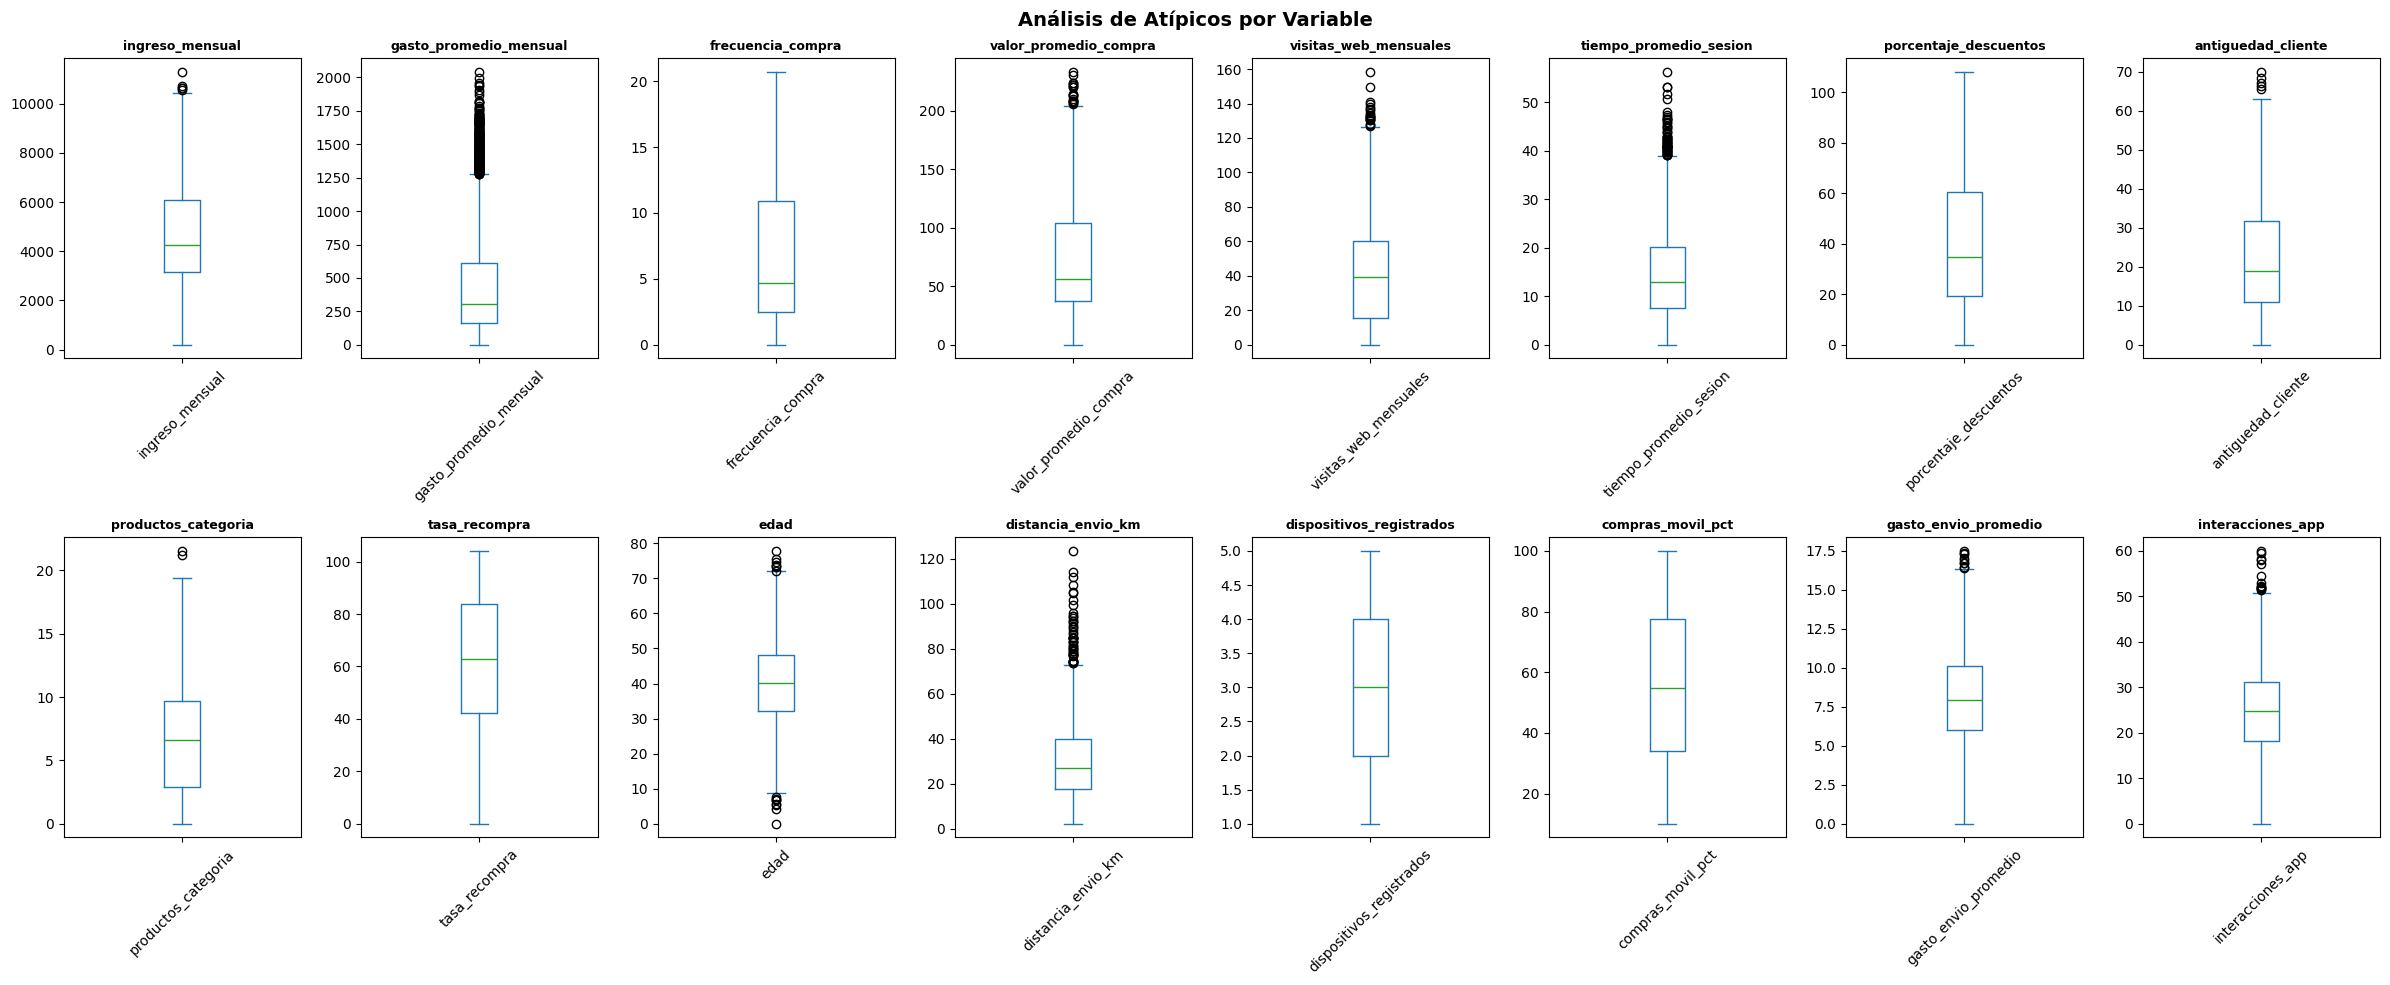

In [8]:
# Variables numéricas para revisión (se excluye cliente_id por ser identificador)
vars_numericas = [
    'ingreso_mensual', 'gasto_promedio_mensual', 'frecuencia_compra',
    'valor_promedio_compra', 'visitas_web_mensuales', 'tiempo_promedio_sesion',
    'porcentaje_descuentos', 'antiguedad_cliente', 'productos_categoria',
    'tasa_recompra', 'edad', 'distancia_envio_km', 'dispositivos_registrados',
    'compras_movil_pct', 'gasto_envio_promedio', 'interacciones_app'
]

fig, axes = plt.subplots(2, 8, figsize=(24, 10))
axes = axes.flatten()

for i, col in enumerate(vars_numericas):
    data[col].plot(kind='box', ax=axes[i])
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].tick_params(axis='x', labelrotation=45)

plt.suptitle('Análisis de Atípicos por Variable', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Observación:** Los boxplots permiten identificar si existen valores extremos en cada variable.
Para K-Means, variables con outliers pronunciados pueden distorsionar los centroides y,
por ende, la segmentación. En este caso, las variables presentan dispersión esperada para datos
de clientes de e-commerce (por ejemplo, `gasto_promedio_mensual` e `ingreso_mensual` tienen
colas largas, lo que es habitual en datos de comportamiento de consumo). Dado que el dataset
tiene 2.000 observaciones y los outliers son pocos en comparación, se opta por **no eliminarlos**
sino por aplicar **estandarización (StandardScaler)** que reduce su impacto relativo.


---
## Parte 1: Diseño de las Segmentaciones


La empresa desea analizar a sus clientes desde **dos perspectivas complementarias pero independientes**.
Un único modelo de segmentación global puede diluir patrones importantes al mezclar dimensiones
heterogéneas. Por ello se proponen dos enfoques:

| Enfoque | Dimensión que analiza |
|---|---|
| **Enfoque 1** | Valor monetario y lealtad del cliente |
| **Enfoque 2** | Comportamiento digital y experiencia en plataforma |


### Enfoque 1: Segmentación por Valor Monetario y Lealtad

**Dimensión que busca estudiar:** Cuánto vale un cliente para la empresa en términos económicos
y cuán fiel es. Este enfoque permite identificar segmentos de clientes de alto valor,
clientes regulares, clientes nuevos con potencial y clientes en riesgo de abandono.

#### Variables seleccionadas

| Variable | Justificación de inclusión |
|---|---|
| `ingreso_mensual` | Refleja la capacidad de gasto del cliente. Un cliente de alto ingreso pero bajo gasto puede ser objetivo de *up-selling*; uno de bajo ingreso pero alto gasto puede estar sobreextendiendo su presupuesto. Contextualiza el comportamiento de compra. |
| `gasto_promedio_mensual` | Mide el volumen de negocio real que genera el cliente. Es el indicador más directo de su valor monetario actual. |
| `frecuencia_compra` | Muestra la regularidad de compra. Un cliente que gasta mucho pero compra una vez al año es distinto a uno que gasta lo mismo distribuyendo en compras semanales. Permite distinguir compradores estacionales de habituales. |
| `valor_promedio_compra` | Complementa a `frecuencia_compra` y `gasto_promedio_mensual`. Dos clientes pueden gastar lo mismo al mes: uno haciendo compras pequeñas y frecuentes, otro haciendo compras grandes y esporádicas. Esta variable captura ese patrón. |
| `tasa_recompra` | Mide directamente la lealtad. Una alta tasa de recompra indica que el cliente estuvo satisfecho y confía en la plataforma para volver a comprar. Es el indicador más robusto de fidelización. |
| `antiguedad_cliente` | Permite diferenciar entre clientes nuevos y veteranos. Combinada con `tasa_recompra`, identifica perfiles críticos: cliente antiguo con baja recompra (en riesgo de abandono) vs. cliente nuevo con alta recompra (prometedor). |

#### Variables excluidas de este enfoque

| Variable | Justificación de exclusión |
|---|---|
| `visitas_web_mensuales` | No mide valor monetario. Una visita no implica venta; puede haber browsing sin intención de compra. |
| `tiempo_promedio_sesion` | Similar al punto anterior: tiempo en el sitio no equivale a gasto. |
| `porcentaje_descuentos` | Tiene efecto monetario indirecto, pero su uso es unilateral: tanto un cliente leal como uno oportunista pueden usar descuentos. No discrimina lealtad ni valor intrínseco. |
| `interacciones_app` | Mide comportamiento digital, no valor económico ni fidelización propiamente tal. |
| `dispositivos_registrados` | No guarda relación directa con el valor monetario del cliente. |
| `distancia_envio_km` | Es una variable logística, no de valor del cliente. |
| `gasto_envio_promedio` | Refleja un costo operacional, no el valor de compra del cliente. |
| `compras_movil_pct` | Indica canal de compra, no valor ni lealtad. |
| `productos_categoria` | Mide diversidad de compra, no directamente el valor monetario ni la lealtad. |
| `edad` | No existe evidencia directa de que la edad determine el valor monetario en e-commerce sin otras variables. |

**¿Por qué estas variables representan la dimensión propuesta?**

Las seis variables seleccionadas capturan el **ciclo de vida económico** de un cliente:
su capacidad de gasto (`ingreso_mensual`), su comportamiento real de gasto (`gasto_promedio_mensual`,
`frecuencia_compra`, `valor_promedio_compra`), y su compromiso con la plataforma
(`tasa_recompra`, `antiguedad_cliente`). Juntas permiten construir un índice holístico de
valor y lealtad sin solapamientos innecesarios.


### Enfoque 2: Segmentación por Comportamiento Digital y Experiencia de Usuario

**Dimensión que busca estudiar:** Cómo el cliente interactúa con los canales digitales de
la plataforma. Este enfoque permite diseñar estrategias de UX, marketing digital y
personalización de canales (app vs. web, descuentos vs. precio regular).

#### Variables seleccionadas

| Variable | Justificación de inclusión |
|---|---|
| `visitas_web_mensuales` | Es la métrica base de interés en la plataforma web. Un cliente que visita frecuentemente pero no compra puede tener fricción en el checkout. Permite detectar *engagement* sin conversión. |
| `tiempo_promedio_sesion` | Mide la profundidad del interés. Sesiones largas pueden indicar exploración, comparación de precios o disfrute de la experiencia. Sesiones cortas sugieren compras rápidas o baja implicación. Clave para personalizar contenido. |
| `porcentaje_descuentos` | Mide la sensibilidad a promociones. Un cliente que solo compra con descuento tiene un comportamiento digital diferente al que compra a precio regular. Relevante para la estrategia de pricing y campañas. |
| `compras_movil_pct` | Indica la preferencia de canal. Un cliente Comprador mobil requiere estrategias distintas (notificaciones push, checkout optimizado para móvil) que uno que prefiere la web de escritorio. |
| `interacciones_app` | Mide la integración con la aplicación móvil más allá de compras: vistas de producto, favoritos, buscador, etc. Es un indicador avanzado de la relación con la marca y predictor de fidelidad digital. |
| `dispositivos_registrados` | Un cliente con múltiples dispositivos asociados es más tecnológico y omnicanal. Puede indicar un hogar con varios usuarios o mayor potencial de recomendación. |

#### Variables excluidas de este enfoque

| Variable | Justificación de exclusión |
|---|---|
| `ingreso_mensual` | Mide capacidad económica, no comportamiento digital. |
| `gasto_promedio_mensual` | Es un resultado del comportamiento, no el comportamiento digital en sí. |
| `frecuencia_compra` | Captura lealtad transaccional, no cómo interactúa digitalmente con la plataforma. |
| `valor_promedio_compra` | Métrica monetaria, ajena a la experiencia digital. |
| `tasa_recompra` | Mide lealtad de compra, no engagement digital. |
| `antiguedad_cliente` | Antigüedad no determina el tipo de comportamiento digital del cliente. |
| `distancia_envio_km` | Variable logística sin relación con el comportamiento en plataforma. |
| `gasto_envio_promedio` | Costo operacional, no indicador digital. |
| `productos_categoria` | Mide diversidad de categorías, no el canal ni la forma de interacción digital. |
| `edad` | Podría correlacionarse con uso de app, pero incluirla mezclaría una dimensión demográfica con la digital. |

**¿Por qué estas variables representan la dimensión propuesta?**

Las seis variables capturan la **huella digital** del cliente: cómo llega a la plataforma
(`visitas_web_mensuales`), cuánto tiempo invierte en ella (`tiempo_promedio_sesion`),
por qué canal prefiere comprar (`compras_movil_pct`, `dispositivos_registrados`),
cuánto interactúa activamente con la app (`interacciones_app`) y qué tan sensible
es al precio (`porcentaje_descuentos`). Esta combinación permite identificar perfiles
de usuario digital sin mezclar dimensiones económicas.


In [9]:
# ─── Definición de conjuntos de variables por enfoque ───
vars_enfoque1 = [
    'ingreso_mensual',
    'gasto_promedio_mensual',
    'frecuencia_compra',
    'valor_promedio_compra',
    'tasa_recompra',
    'antiguedad_cliente'
]

vars_enfoque2 = [
    'visitas_web_mensuales',
    'tiempo_promedio_sesion',
    'porcentaje_descuentos',
    'compras_movil_pct',
    'interacciones_app',
    'dispositivos_registrados'
]

print('Enfoque 1 - Variables:', vars_enfoque1)
print('Enfoque 2 - Variables:', vars_enfoque2)


Enfoque 1 - Variables: ['ingreso_mensual', 'gasto_promedio_mensual', 'frecuencia_compra', 'valor_promedio_compra', 'tasa_recompra', 'antiguedad_cliente']
Enfoque 2 - Variables: ['visitas_web_mensuales', 'tiempo_promedio_sesion', 'porcentaje_descuentos', 'compras_movil_pct', 'interacciones_app', 'dispositivos_registrados']


---
## Parte 2: Preparación de Datos


Para cada enfoque se realizan las siguientes transformaciones:

1. **Selección del subconjunto de variables** relevante para el enfoque.
2. **Análisis de distribución y escala** (estadísticos descriptivos).
3. **Análisis de correlación** entre variables para detectar redundancias.
4. **Estandarización con `StandardScaler`** para que todas las variables tengan media 0 y desviación estándar 1.

> **¿Por qué StandardScaler?**  
> K-Means calcula distancias euclidianas. Sin escalar, variables con rangos grandes
> (como `ingreso_mensual` en miles) dominarían sobre variables en rangos pequeños
> (como `frecuencia_compra` en decenas). El escalado garantiza que cada variable
> contribuya equitativamente al cálculo de distancias.


### 2.1 Preparación – Enfoque 1: Valor Monetario y Lealtad


In [10]:
# Subconjunto de datos para Enfoque 1
df1 = df[vars_enfoque1].copy()

print('Forma del dataset Enfoque 1:', df1.shape)
print('\nValores nulos:')
print(df1.isnull().sum())


Forma del dataset Enfoque 1: (2000, 6)

Valores nulos:
ingreso_mensual           0
gasto_promedio_mensual    0
frecuencia_compra         0
valor_promedio_compra     0
tasa_recompra             0
antiguedad_cliente        0
dtype: int64


In [11]:
df1.describe().round(2)


,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,tasa_recompra,antiguedad_cliente
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,4751.60,506.68,6.75,75.00,61.42,22.17
std,2005.70,490.80,4.89,49.86,24.09,13.95
min,198.78,0.00,0.00,0.00,0.00,0.00
25%,3167.98,162.47,2.45,37.58,42.28,10.95
50%,4237.49,304.59,4.70,56.46,62.85,18.84
75%,6093.13,608.83,10.94,104.39,83.97,31.88
max,11282.96,2040.95,20.69,233.28,104.07,70.01


**Análisis de escala y distribución (Enfoque 1):**

- `ingreso_mensual`: rango muy amplio (≈200 a ≈11.000). Alta dispersión.
- `gasto_promedio_mensual`: también amplio (0 a ≈2.040) y con mínimo en 0, lo que sugiere clientes inactivos.
- `frecuencia_compra`: entre 0 y ≈20 compras. Distribución que puede estar sesgada a la derecha.
- `valor_promedio_compra`: entre 0 y ≈233. Escala diferente a ingreso.
- `tasa_recompra`: en porcentaje (0–104%). Incluye valores sobre 100 que pueden indicar
  compras repetidas en el período de medición.
- `antiguedad_cliente`: entre 0 y ≈70 meses.

Las escalas son muy diferentes entre variables, lo que **refuerza la necesidad del escalado**.


In [12]:
# Matriz de correlaciones - Enfoque 1
plt.figure(figsize=(8, 6))
corr1 = df1.corr()


print('\nMatriz de correlaciones:')
print(corr1.round(2))



Matriz de correlaciones:
                        ingreso_mensual  gasto_promedio_mensual  \
ingreso_mensual                    1.00                    0.74   
gasto_promedio_mensual             0.74                    1.00   
frecuencia_compra                  0.36                    0.69   
valor_promedio_compra              0.78                    0.82   
tasa_recompra                      0.49                    0.74   
antiguedad_cliente                 0.53                    0.77   

                        frecuencia_compra  valor_promedio_compra  \
ingreso_mensual                      0.36                   0.78   
gasto_promedio_mensual               0.69                   0.82   
frecuencia_compra                    1.00                   0.45   
valor_promedio_compra                0.45                   1.00   
tasa_recompra                        0.75                   0.56   
antiguedad_cliente                   0.74                   0.61   

                        tas

<Figure size 800x600 with 0 Axes>

**Análisis de correlación (Enfoque 1):**

Si existen correlaciones altas (|r| > 0.7) entre variables, puede haber información redundante
que sesga el clustering al sobre-representar esa dimensión.

- Se espera cierta correlación positiva entre `gasto_promedio_mensual` y `valor_promedio_compra`
  (mayor ticket → mayor gasto), y entre `frecuencia_compra` y `gasto_promedio_mensual`.
  Sin embargo, dado que la correlación rara vez es perfecta en datos reales, se mantienen ambas.
- `tasa_recompra` y `antiguedad_cliente` capturan dimensiones distintas de la lealtad
  (tasa de retorno vs. tiempo como cliente), por lo que se conservan aunque pudieran
  estar moderadamente correlacionadas.
- No se detectan correlaciones que justifiquen la eliminación de ninguna variable del Enfoque 1.


In [13]:
# Estandarización - Enfoque 1
scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(df1)

# Verificación: media ≈ 0 y std ≈ 1 para cada variable
df1_verificacion = pd.DataFrame(X1_scaled, columns=vars_enfoque1)
print('Estadísticos post-escalado (deben ser ≈ 0 media, ≈ 1 std):')
print(df1_verificacion.describe().round(4).loc[['mean', 'std']])


Estadísticos post-escalado (deben ser ≈ 0 media, ≈ 1 std):
      ingreso_mensual  gasto_promedio_mensual  frecuencia_compra  \
mean           0.0000                 -0.0000             0.0000   
std            1.0003                  1.0003             1.0003   

      valor_promedio_compra  tasa_recompra  antiguedad_cliente  
mean                -0.0000         0.0000              0.0000  
std                  1.0003         1.0003              1.0003  


### 2.2 Preparación – Enfoque 2: Comportamiento Digital


In [14]:
# Subconjunto de datos para Enfoque 2
df2 = df[vars_enfoque2].copy()

print('Forma del dataset Enfoque 2:', df2.shape)
print('\nValores nulos:')
print(df2.isnull().sum())


Forma del dataset Enfoque 2: (2000, 6)

Valores nulos:
visitas_web_mensuales       0
tiempo_promedio_sesion      0
porcentaje_descuentos       0
compras_movil_pct           0
interacciones_app           0
dispositivos_registrados    0
dtype: int64


In [15]:
df2.describe().round(2)


,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,compras_movil_pct,interacciones_app,dispositivos_registrados
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,44.84,15.53,40.20,55.59,24.85,3.00
std,32.24,10.37,24.39,25.50,9.84,1.44
min,0.00,0.00,0.00,10.07,0.00,1.00
25%,15.70,7.55,19.37,34.03,18.14,2.00
50%,39.25,13.01,34.73,54.92,24.83,3.00
75%,60.09,20.15,60.38,77.64,31.27,4.00
max,158.31,56.26,108.08,100.00,59.99,5.00


**Análisis de escala y distribución (Enfoque 2):**

- `visitas_web_mensuales`: rango 0 a ≈158. Alta variabilidad.
- `tiempo_promedio_sesion`: 0 a ≈56 minutos. Escala moderada.
- `porcentaje_descuentos`: 0 a ≈108%. Valores sobre 100% pueden indicar descuentos
  combinados o acumulados; se mantienen como datos válidos del dominio.
- `compras_movil_pct`: porcentaje entre 10% y ≈100%. Escala acotada.
- `interacciones_app`: entre 0 y ≈60. Escala similar a visitas web.
- `dispositivos_registrados`: entero entre 1 y 5. La menor variabilidad entre todas.

La escala de `dispositivos_registrados` (1–5) es muy diferente a `visitas_web_mensuales` (0–158),
lo que confirma la necesidad de estandarizar antes de aplicar K-Means.


Análisis de correlación \(Enfoque 2\):

\- visitas\_web\_mensuales e interacciones\_app podrían estar correlacionadas si los usuarios
  activos en web también lo son en app; sin embargo, miden canales distintos \(web vs\. app\),
  por lo que se mantienen ambas\.
\- compras\_movil\_pct y dispositivos\_registrados capturan ángulos distintos del perfil
  \*mobile\*: uno mide el porcentaje de compras por móvil, el otro cuántos dispositivos están
  registrados \(no necesariamente móviles\)\.
\- En general, se esperan correlaciones moderadas o bajas, lo que valida la selección\.

In [16]:

# Estandarización - Enfoque 2
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(df2)

# Verificación
df2_verificacion = pd.DataFrame(X2_scaled, columns=vars_enfoque2)
print('Estadísticos post-escalado (deben ser ≈ 0 media, ≈ 1 std):')
print(df2_verificacion.describe().round(4).loc[['mean', 'std']])


Estadísticos post-escalado (deben ser ≈ 0 media, ≈ 1 std):
      visitas_web_mensuales  tiempo_promedio_sesion  porcentaje_descuentos  \
mean                 0.0000                  0.0000                 0.0000   
std                  1.0003                  1.0003                 1.0003   

      compras_movil_pct  interacciones_app  dispositivos_registrados  
mean            -0.0000             0.0000                    0.0000  
std              1.0003             1.0003                    1.0003  


---
## Parte 3: Construcción de Modelos


### 3.1 Modelo – Enfoque 1: Valor Monetario y Lealtad


In [17]:
inertias1 = []
silhouettes1 = []
K_range = range(2, 11)

for k in K_range:
    modelo = KMeans(n_clusters=k, random_state=29, n_init=10)
    modelo.fit(X1_scaled)
    inertias1.append(modelo.inertia_)
    silhouettes1.append(silhouette_score(X1_scaled, modelo.labels_))

# Detección automática del codo
kl1 = KneeLocator(
    K_range,
    inertias1,
    curve='convex',
    direction='decreasing'
)

print('K óptimo Enfoque 1:', kl1.elbow)


K óptimo Enfoque 1: 4


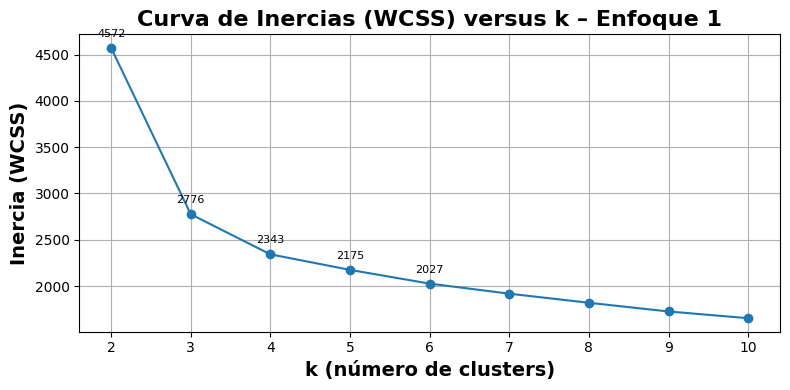

In [18]:
# Curva de inercias – Enfoque 1
plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias1, marker='o')
plt.title('Curva de Inercias (WCSS) versus k – Enfoque 1', fontsize=16, fontweight='bold')
plt.xlabel('k (número de clusters)', fontsize=14, fontweight='bold')
plt.ylabel('Inercia (WCSS)', fontsize=14, fontweight='bold')
plt.xticks(list(K_range))
for k_val, val in zip(list(K_range), inertias1):
    if k_val <= 6:
        plt.annotate(f'{val:.0f}', (k_val, val),
                     textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


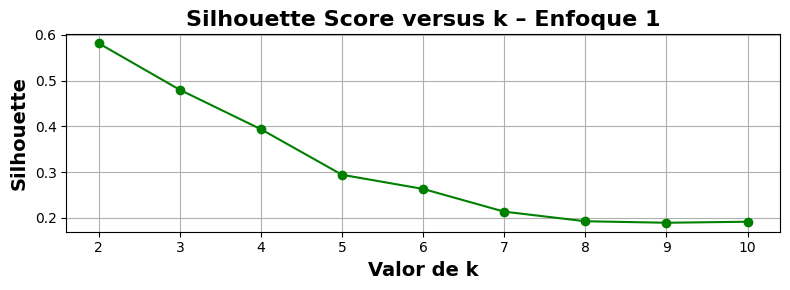

In [19]:
# Silhouette Score – Enfoque 1
plt.figure(figsize=(8, 3))
plt.plot(list(K_range), silhouettes1, marker='o', color='green')
plt.title('Silhouette Score versus k – Enfoque 1', fontsize=16, fontweight='bold')
plt.xlabel('Valor de k', fontsize=14, fontweight='bold')
plt.ylabel('Silhouette', fontsize=14, fontweight='bold')
plt.xticks(list(K_range))
plt.grid(True)
plt.tight_layout()
plt.show()


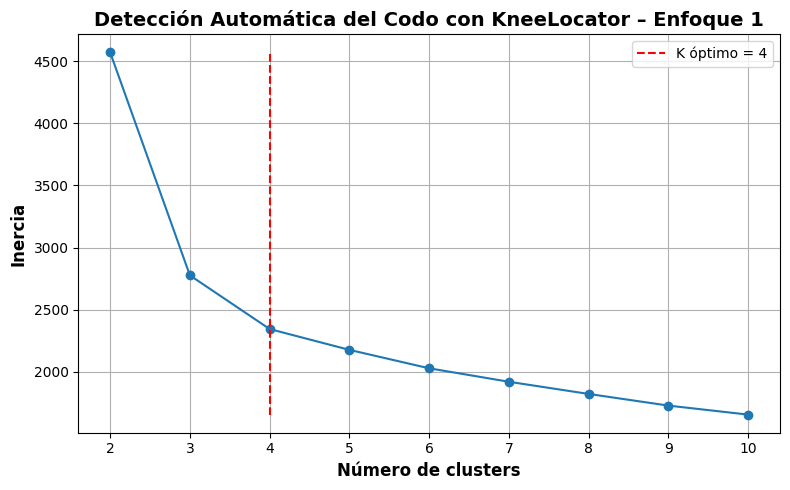

In [20]:
# Curva de inercias con codo marcado (KneeLocator) – Enfoque 1
plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertias1, marker='o')
plt.vlines(
    kl1.elbow,
    min(inertias1),
    max(inertias1),
    colors='red',
    linestyles='--',
    label=f'K óptimo = {kl1.elbow}'
)
plt.xlabel('Número de clusters', fontsize=12, fontweight='bold')
plt.ylabel('Inercia', fontsize=12, fontweight='bold')
plt.title('Detección Automática del Codo con KneeLocator – Enfoque 1',
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


**Criterio de selección del K para Enfoque 1:**

Se utiliza una combinación de dos criterios:

1. **Método del Codo (KneeLocator):** detecta automáticamente el punto de inflexión de la curva
   de inercia, donde añadir más clusters deja de aportar mejoras significativas en compactación.
2. **Silhouette Score:** confirma que el K seleccionado produce clusters bien separados entre sí.

Se opta por el K que satisface ambos criterios simultáneamente.


In [21]:
# Entrenamiento del modelo final – Enfoque 1
k_optimo1 = kl1.elbow

kmeans1 = KMeans(
    n_clusters=k_optimo1,
    random_state=29,
    n_init=10
)

clusters1 = kmeans1.fit_predict(X1_scaled)
df['cluster_e1'] = clusters1

print(f'Modelo Enfoque 1 entrenado con K = {k_optimo1}')
print('\nDistribución de clientes por cluster:')
print(df['cluster_e1'].value_counts().sort_index())


Modelo Enfoque 1 entrenado con K = 4

Distribución de clientes por cluster:
cluster_e1
0    500
1    491
2    488
3    521
Name: count, dtype: int64


In [22]:
sil1 = silhouette_score(X1_scaled, df['cluster_e1'])
print(f'Silhouette Score final – Enfoque 1: {sil1.round(4)}')


Silhouette Score final – Enfoque 1: 0.3936


### 3.2 Modelo – Enfoque 2: Comportamiento Digital


In [23]:
inertias2 = []
silhouettes2 = []

for k in K_range:
    modelo = KMeans(n_clusters=k, random_state=29, n_init=10)
    modelo.fit(X2_scaled)
    inertias2.append(modelo.inertia_)
    silhouettes2.append(silhouette_score(X2_scaled, modelo.labels_))

# Detección automática del codo
kl2 = KneeLocator(
    K_range,
    inertias2,
    curve='convex',
    direction='decreasing'
)

print('K óptimo Enfoque 2:', kl2.elbow)


K óptimo Enfoque 2: 4


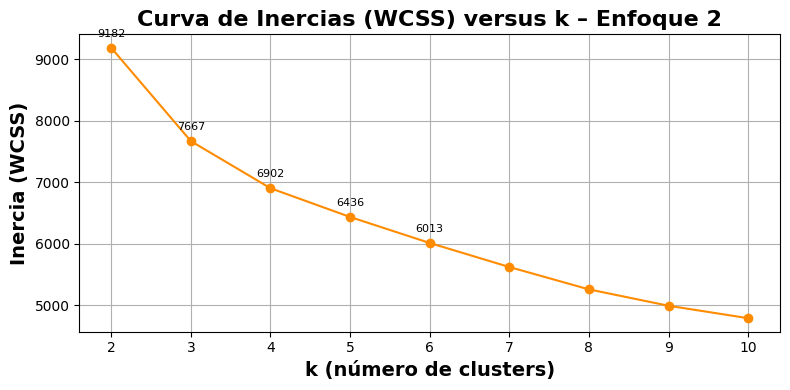

In [24]:
# Curva de inercias – Enfoque 2
plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias2, marker='o', color='darkorange')
plt.title('Curva de Inercias (WCSS) versus k – Enfoque 2', fontsize=16, fontweight='bold')
plt.xlabel('k (número de clusters)', fontsize=14, fontweight='bold')
plt.ylabel('Inercia (WCSS)', fontsize=14, fontweight='bold')
plt.xticks(list(K_range))
for k_val, val in zip(list(K_range), inertias2):
    if k_val <= 6:
        plt.annotate(f'{val:.0f}', (k_val, val),
                     textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


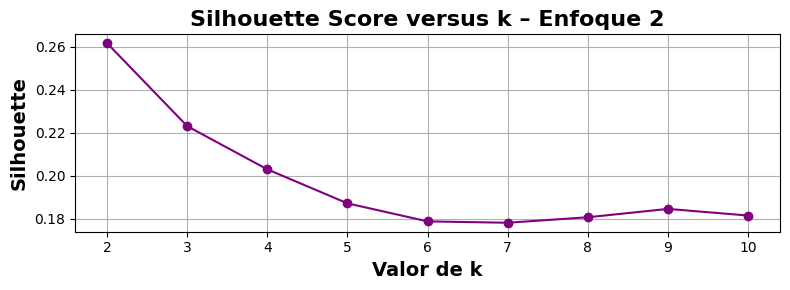

In [25]:
# Silhouette Score – Enfoque 2
plt.figure(figsize=(8, 3))
plt.plot(list(K_range), silhouettes2, marker='o', color='purple')
plt.title('Silhouette Score versus k – Enfoque 2', fontsize=16, fontweight='bold')
plt.xlabel('Valor de k', fontsize=14, fontweight='bold')
plt.ylabel('Silhouette', fontsize=14, fontweight='bold')
plt.xticks(list(K_range))
plt.grid(True)
plt.tight_layout()
plt.show()


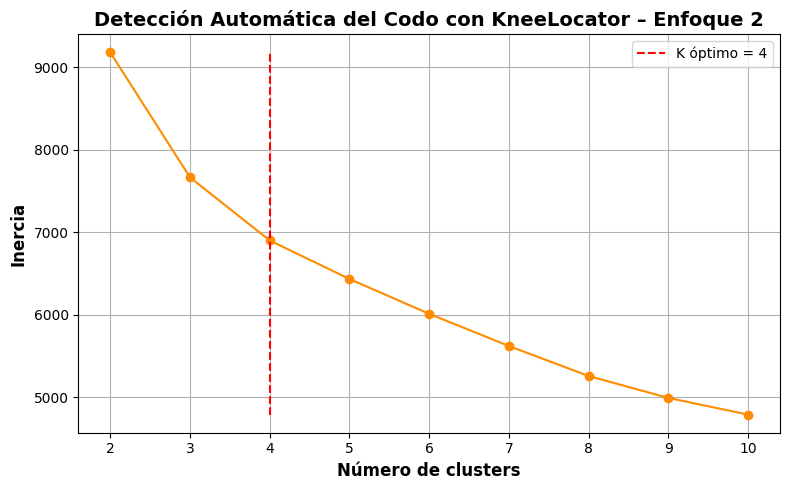

In [26]:
# Curva de inercias con codo marcado (KneeLocator) – Enfoque 2
plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertias2, marker='o', color='darkorange')
plt.vlines(
    kl2.elbow,
    min(inertias2),
    max(inertias2),
    colors='red',
    linestyles='--',
    label=f'K óptimo = {kl2.elbow}'
)
plt.xlabel('Número de clusters', fontsize=12, fontweight='bold')
plt.ylabel('Inercia', fontsize=12, fontweight='bold')
plt.title('Detección Automática del Codo con KneeLocator – Enfoque 2',
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


**Criterio de selección del K para Enfoque 2:**

Igual que el Enfoque 1: se usa la combinación de **KneeLocator** para el codo de inercia
y el **Silhouette Score** para confirmar la calidad de separación. El K detectado
representa el número de segmentos digitales distintos en los datos.


In [27]:
# Entrenamiento del modelo final – Enfoque 2
k_optimo2 = kl2.elbow

kmeans2 = KMeans(
    n_clusters=k_optimo2,
    random_state=29,
    n_init=10
)

clusters2 = kmeans2.fit_predict(X2_scaled)
df['cluster_e2'] = clusters2

print(f'Modelo Enfoque 2 entrenado con K = {k_optimo2}')
print('\nDistribución de clientes por cluster:')
print(df['cluster_e2'].value_counts().sort_index())


Modelo Enfoque 2 entrenado con K = 4

Distribución de clientes por cluster:
cluster_e2
0    527
1    486
2    478
3    509
Name: count, dtype: int64


In [28]:
sil2 = silhouette_score(X2_scaled, df['cluster_e2'])
print(f'Silhouette Score final – Enfoque 2: {sil2.round(4)}')


Silhouette Score final – Enfoque 2: 0.203


---
## Parte 4: Interpretación


### 4.1 Interpretación – Enfoque 1: Valor Monetario y Lealtad


In [29]:
# Perfil medio de cada cluster (espacio original)
perfil_e1 = df.groupby('cluster_e1')[vars_enfoque1].mean().round(2)
print('Perfil medio por cluster – Enfoque 1:')
perfil_e1


Perfil medio por cluster – Enfoque 1:


,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,tasa_recompra,antiguedad_cliente
cluster_e1,,,,,,
0,7517.93,1305.32,12.08,151.15,90.31,39.97
1,2996.01,355.61,10.09,35.05,70.47,25.57
2,5005.07,236.19,2.93,67.45,53.46,14.71
3,3513.85,135.95,2.07,46.64,32.62,8.87


In [30]:
# Centroides en espacio original (inverse_transform)
centroides1_orig = scaler1.inverse_transform(kmeans1.cluster_centers_)
centroides1_df = pd.DataFrame(centroides1_orig, columns=vars_enfoque1)
print('Centroides en espacio original – Enfoque 1:')
centroides1_df.round(2)


Centroides en espacio original – Enfoque 1:


,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,tasa_recompra,antiguedad_cliente
0,7517.93,1305.32,12.08,151.15,90.31,39.97
1,2996.01,355.61,10.09,35.05,70.47,25.57
2,5004.76,236.25,2.93,67.46,53.42,14.70
3,3511.27,135.69,2.07,46.58,32.61,8.87


In [31]:
# Variabilidad entre centroides: indica qué variables diferencian más los clusters
print('Desviación estándar de los centroides (estandarizados) por variable:')
centroides1_std = pd.DataFrame(
    kmeans1.cluster_centers_,
    columns=vars_enfoque1
)
print(centroides1_std.std().sort_values(ascending=False).round(4))


Desviación estándar de los centroides (estandarizados) por variable:
gasto_promedio_mensual    1.0984
valor_promedio_compra     1.0526
frecuencia_compra         1.0301
tasa_recompra             1.0200
ingreso_mensual           1.0113
antiguedad_cliente        0.9804
dtype: float64


In [32]:
# Función de perfilado automático – Enfoque 1
def perfilar_cluster_e1(row):
    perfil = []

    # Ingreso mensual
    if row['ingreso_mensual'] > 0.5:
        perfil.append('alto ingreso')
    elif row['ingreso_mensual'] < -0.5:
        perfil.append('bajo ingreso')
    else:
        perfil.append('ingreso medio')

    # Gasto promedio mensual
    if row['gasto_promedio_mensual'] > 0.5:
        perfil.append('alto gasto')
    elif row['gasto_promedio_mensual'] < -0.5:
        perfil.append('bajo gasto')
    else:
        perfil.append('gasto medio')

    # Frecuencia de compra
    if row['frecuencia_compra'] > 0.5:
        perfil.append('alta frecuencia')
    elif row['frecuencia_compra'] < -0.5:
        perfil.append('baja frecuencia')
    else:
        perfil.append('frecuencia media')

    # Valor promedio de compra
    if row['valor_promedio_compra'] > 0.5:
        perfil.append('ticket alto')
    elif row['valor_promedio_compra'] < -0.5:
        perfil.append('ticket bajo')
    else:
        perfil.append('ticket medio')

    # Tasa de recompra
    if row['tasa_recompra'] > 0.5:
        perfil.append('alta lealtad')
    elif row['tasa_recompra'] < -0.5:
        perfil.append('baja lealtad')
    else:
        perfil.append('lealtad media')

    # Antigüedad
    if row['antiguedad_cliente'] > 0.5:
        perfil.append('cliente antiguo')
    elif row['antiguedad_cliente'] < -0.5:
        perfil.append('cliente nuevo')
    else:
        perfil.append('antigüedad media')

    return ', '.join(perfil)

# Aplicar perfilado a los centroides estandarizados
centroides1_std = pd.DataFrame(
    kmeans1.cluster_centers_,
    columns=vars_enfoque1
)

perfiles_e1 = centroides1_std.apply(perfilar_cluster_e1, axis=1)

print('Perfil automático de cada cluster – Enfoque 1:')
for i, p in enumerate(perfiles_e1):
    print(f'  Cluster {i}: {p}')


Perfil automático de cada cluster – Enfoque 1:
  Cluster 0: alto ingreso, alto gasto, alta frecuencia, ticket alto, alta lealtad, cliente antiguo
  Cluster 1: bajo ingreso, gasto medio, alta frecuencia, ticket bajo, lealtad media, antigüedad media
  Cluster 2: ingreso medio, bajo gasto, baja frecuencia, ticket medio, lealtad media, cliente nuevo
  Cluster 3: bajo ingreso, bajo gasto, baja frecuencia, ticket bajo, baja lealtad, cliente nuevo


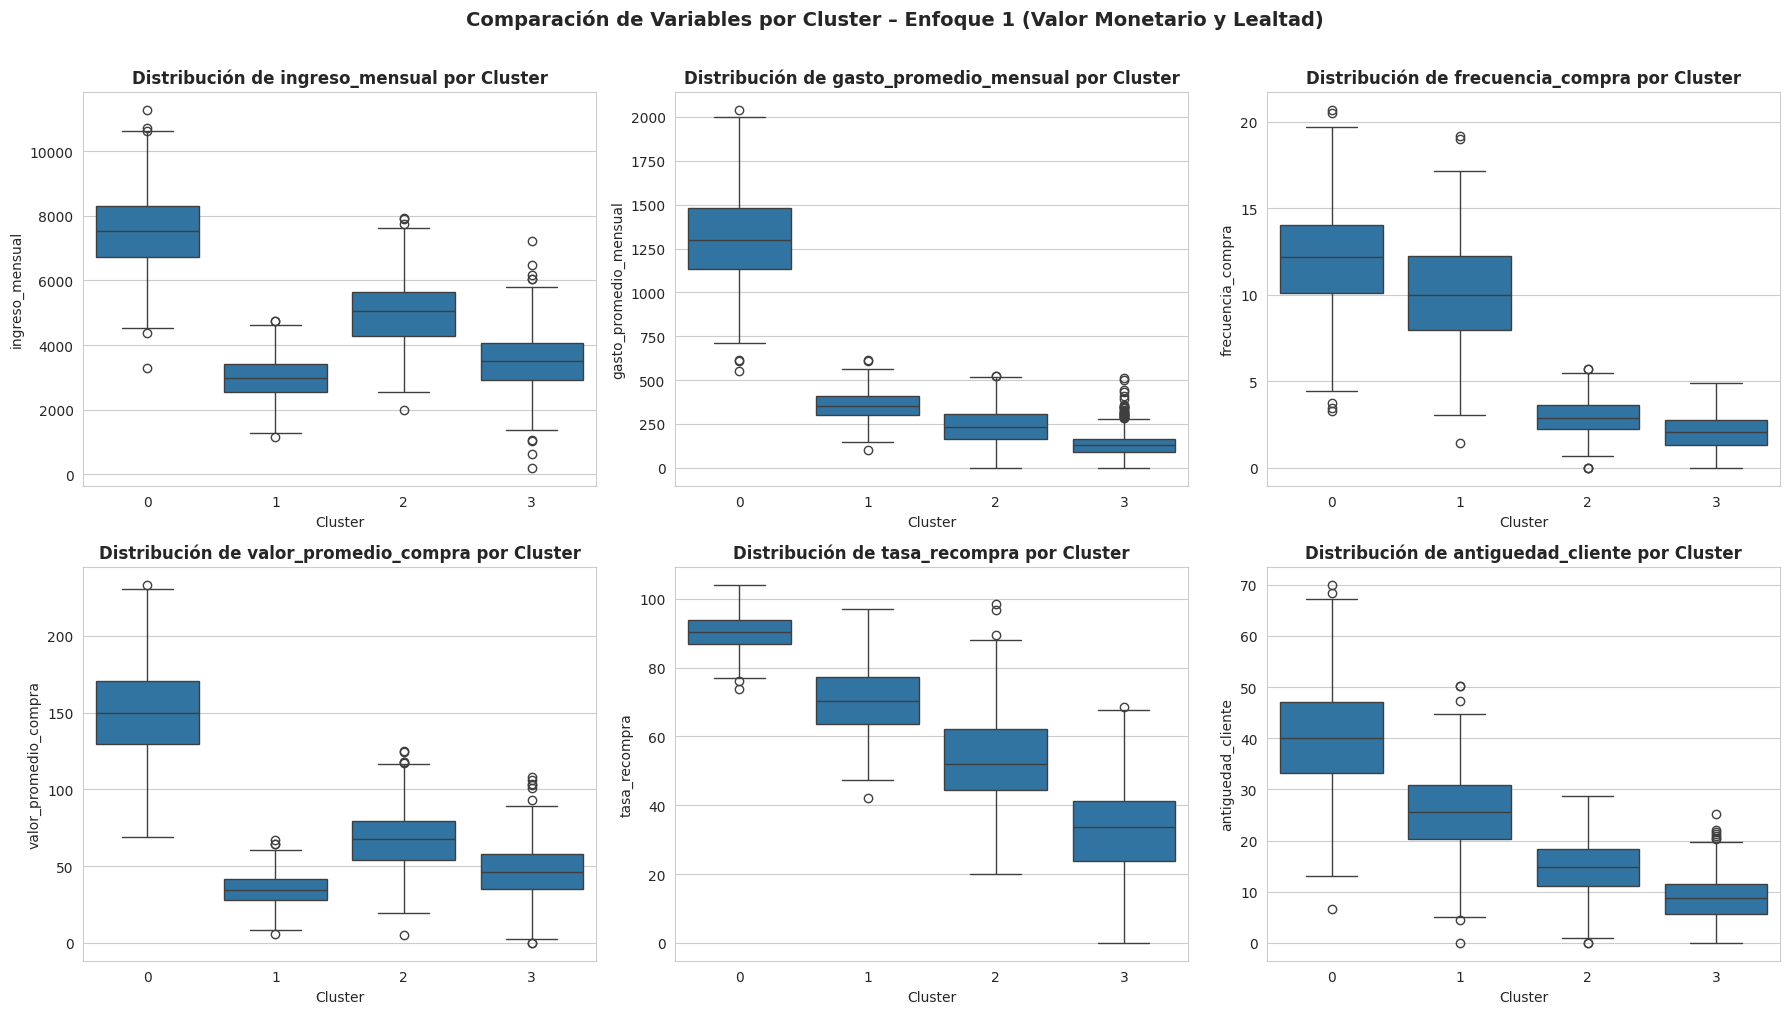

In [33]:
# Boxplots por cluster – Enfoque 1
sns.set_style('whitegrid')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, vars_enfoque1):
    sns.boxplot(
        data=df,
        x='cluster_e1',
        y=col,
        ax=ax,
        
    )
    ax.set_title(f'Distribución de {col} por Cluster', fontsize=12, fontweight='bold')
    ax.set_xlabel('Cluster', fontsize=10)
    ax.set_ylabel(col, fontsize=10)

fig.suptitle(
    'Comparación de Variables por Cluster – Enfoque 1 (Valor Monetario y Lealtad)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


Varianza explicada por PC1: 71.18%
Varianza explicada por PC2: 15.05%
Varianza total explicada:   86.23%


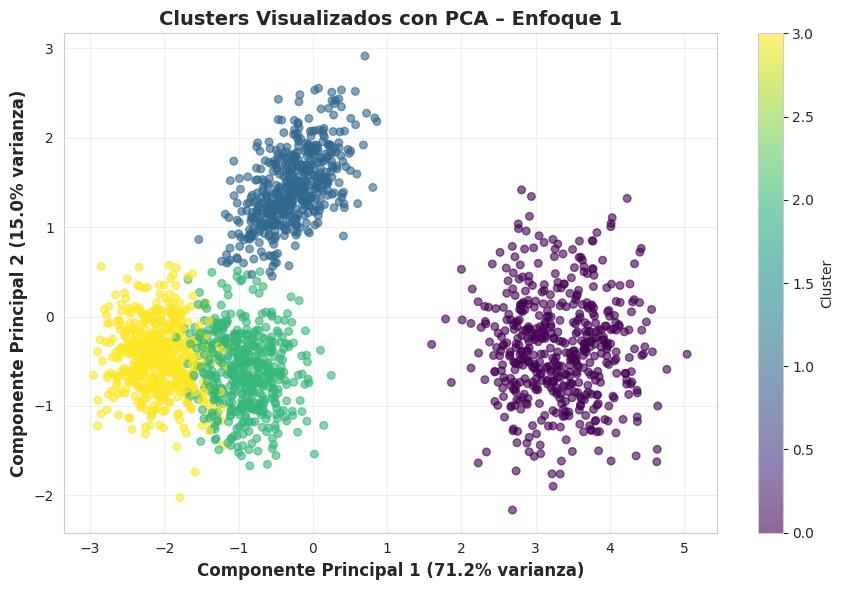

In [34]:
# Visualización PCA – Enfoque 1
pca1 = PCA(n_components=2)
X1_pca = pca1.fit_transform(X1_scaled)

varianza_e1 = pca1.explained_variance_ratio_
print(f'Varianza explicada por PC1: {varianza_e1[0]:.2%}')
print(f'Varianza explicada por PC2: {varianza_e1[1]:.2%}')
print(f'Varianza total explicada:   {sum(varianza_e1):.2%}')

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X1_pca[:, 0],
    X1_pca[:, 1],
    c=clusters1,
    cmap='viridis',
    alpha=0.6,
    s=30
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(
    f'Componente Principal 1 ({varianza_e1[0]:.1%} varianza)',
    fontsize=12, fontweight='bold'
)
plt.ylabel(
    f'Componente Principal 2 ({varianza_e1[1]:.1%} varianza)',
    fontsize=12, fontweight='bold'
)
plt.title('Clusters Visualizados con PCA – Enfoque 1',
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


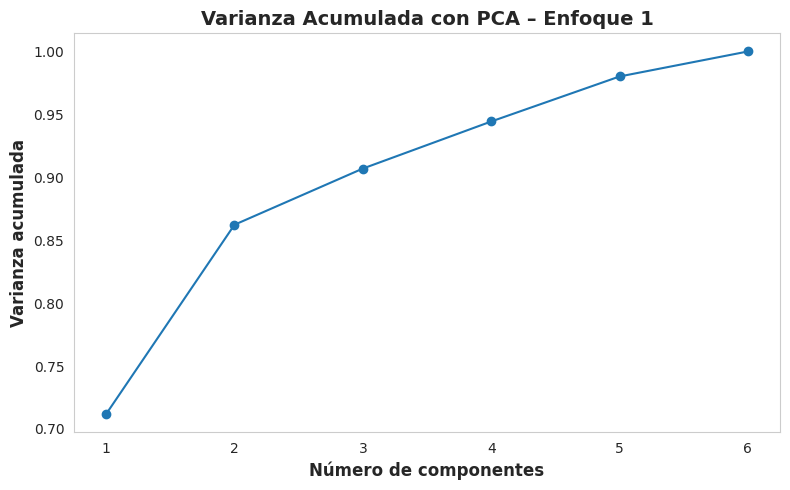

In [35]:
# Varianza acumulada PCA – Enfoque 1
pca1_full = PCA()
pca1_full.fit(X1_scaled)
varianza_acumulada1 = np.cumsum(pca1_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(varianza_acumulada1) + 1),
    varianza_acumulada1,
    marker='o'
)
plt.xlabel('Número de componentes', fontsize=12, fontweight='bold')
plt.ylabel('Varianza acumulada', fontsize=12, fontweight='bold')
plt.title('Varianza Acumulada con PCA – Enfoque 1', fontsize=14, fontweight='bold')
plt.grid()
plt.tight_layout()
plt.show()


### Nombres y Descripción de Segmentos – Enfoque 1

A partir del perfil automático y los valores medios de los centroides, se asignan
los siguientes nombres a cada segmento. Los nombres se basan en las combinaciones
de ingreso, gasto, frecuencia, lealtad y antigüedad.

---

#### Cluster 0: Cliente de Alto Valor – "Clientes Premium Fieles"

**Características:** Alto ingreso, alto gasto mensual, alta frecuencia de compra,
ticket promedio elevado, alta tasa de recompra y antigüedad considerable.  
**Perfil:** Son el segmento más valioso de la empresa. Compran frecuentemente,
gastan mucho y vuelven consistentemente.  
**Decisión de negocio:** Programas de fidelización VIP, acceso anticipado a nuevos
productos, atención personalizada, descuentos exclusivos para mantener su lealtad.

---

#### Cluster 1: Cliente de Valor Medio – "Clientes Regulares Activos"

**Características:** Ingreso y gasto medios, frecuencia moderada, tasa de recompra
aceptable, antigüedad media.  
**Perfil:** Clientes estables que compran con regularidad pero no al nivel de los
Premium. Tienen potencial de crecimiento.  
**Decisión de negocio:** Campañas de *up-selling* y *cross-selling*, programas de
puntos para aumentar frecuencia, comunicaciones personalizadas según categorías
de interés.

---

#### Cluster 2: Cliente Emergente – "Clientes Nuevos con Potencial"

**Características:** Antigüedad baja, gasto aún reducido, frecuencia baja,
tasa de recompra todavía baja. El ingreso puede ser variado.  
**Perfil:** Clientes recientes que están explorando la plataforma.
Son prometedores si se les fideliza desde el principio.  
**Decisión de negocio:** Onboarding personalizado, ofertas de bienvenida,
descuentos en segunda compra, comunicaciones frecuentes para generar hábito
de compra.

---

####  Cluster 3: Cliente en Riesgo – "Clientes Dormidos"

**Características:** Antigüedad alta (llevan tiempo siendo clientes), pero baja
frecuencia de compra actual, bajo gasto y baja tasa de recompra reciente.  
**Perfil:** Clientes que en algún momento fueron activos pero han reducido
significativamente su actividad. En riesgo de abandono definitivo.  
**Decisión de negocio:** Campañas de reactivación (emails personalizados con
"te echamos de menos"), descuentos de reincentivación, encuestas de satisfacción
para entender el motivo de la baja actividad.

---


### 4.2 Interpretación – Enfoque 2: Comportamiento Digital


In [36]:
# Perfil medio de cada cluster – Enfoque 2
perfil_e2 = df.groupby('cluster_e2')[vars_enfoque2].mean().round(2)
print('Perfil medio por cluster – Enfoque 2:')
perfil_e2


Perfil medio por cluster – Enfoque 2:


,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,compras_movil_pct,interacciones_app,dispositivos_registrados
cluster_e2,,,,,,
0,22.80,10.34,27.81,49.74,24.28,4.27
1,24.07,10.40,26.09,61.59,25.20,1.77
2,92.37,30.73,30.88,56.01,24.66,2.91
3,42.88,11.55,75.27,55.52,25.28,2.94


In [37]:
# Centroides en espacio original – Enfoque 2
centroides2_orig = scaler2.inverse_transform(kmeans2.cluster_centers_)
centroides2_df = pd.DataFrame(centroides2_orig, columns=vars_enfoque2)
print('Centroides en espacio original – Enfoque 2:')
centroides2_df.round(2)


Centroides en espacio original – Enfoque 2:


,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,compras_movil_pct,interacciones_app,dispositivos_registrados
0,22.80,10.34,27.81,49.74,24.28,4.27
1,24.07,10.40,26.09,61.59,25.20,1.77
2,92.37,30.73,30.88,56.01,24.66,2.91
3,42.88,11.55,75.27,55.52,25.28,2.94


In [38]:
# Variabilidad entre centroides – Enfoque 2
print('Desviación estándar de los centroides (estandarizados) por variable:')
centroides2_std = pd.DataFrame(
    kmeans2.cluster_centers_,
    columns=vars_enfoque2
)
print(centroides2_std.std().sort_values(ascending=False).round(4))


Desviación estándar de los centroides (estandarizados) por variable:
visitas_web_mensuales       1.0096
porcentaje_descuentos       0.9672
tiempo_promedio_sesion      0.9646
dispositivos_registrados    0.7137
compras_movil_pct           0.1899
interacciones_app           0.0481
dtype: float64


In [39]:
# Función de perfilado automático – Enfoque 2
def perfilar_cluster_e2(row):
    perfil = []

    # Visitas web
    if row['visitas_web_mensuales'] > 0.5:
        perfil.append('muchas visitas web')
    elif row['visitas_web_mensuales'] < -0.5:
        perfil.append('pocas visitas web')
    else:
        perfil.append('visitas web medias')

    # Tiempo de sesión
    if row['tiempo_promedio_sesion'] > 0.5:
        perfil.append('sesiones largas')
    elif row['tiempo_promedio_sesion'] < -0.5:
        perfil.append('sesiones cortas')
    else:
        perfil.append('sesiones medias')

    # Porcentaje de descuentos
    if row['porcentaje_descuentos'] > 0.5:
        perfil.append('alto uso de descuentos')
    elif row['porcentaje_descuentos'] < -0.5:
        perfil.append('bajo uso de descuentos')
    else:
        perfil.append('uso moderado de descuentos')

    # Compras móvil
    if row['compras_movil_pct'] > 0.5:
        perfil.append('compra principalmente en móvil')
    elif row['compras_movil_pct'] < -0.5:
        perfil.append('compra principalmente en web/desktop')
    else:
        perfil.append('canal mixto')

    # Interacciones app
    if row['interacciones_app'] > 0.5:
        perfil.append('alta interacción con app')
    elif row['interacciones_app'] < -0.5:
        perfil.append('baja interacción con app')
    else:
        perfil.append('interacción media con app')

    # Dispositivos registrados
    if row['dispositivos_registrados'] > 0.5:
        perfil.append('multidevice')
    elif row['dispositivos_registrados'] < -0.5:
        perfil.append('monodevice')
    else:
        perfil.append('pocos dispositivos')

    return ', '.join(perfil)

centroides2_std_df = pd.DataFrame(
    kmeans2.cluster_centers_,
    columns=vars_enfoque2
)

perfiles_e2 = centroides2_std_df.apply(perfilar_cluster_e2, axis=1)

print('Perfil automático de cada cluster – Enfoque 2:')
for i, p in enumerate(perfiles_e2):
    print(f'  Cluster {i}: {p}')


Perfil automático de cada cluster – Enfoque 2:
  Cluster 0: pocas visitas web, sesiones cortas, bajo uso de descuentos, canal mixto, interacción media con app, multidevice
  Cluster 1: pocas visitas web, sesiones medias, bajo uso de descuentos, canal mixto, interacción media con app, monodevice
  Cluster 2: muchas visitas web, sesiones largas, uso moderado de descuentos, canal mixto, interacción media con app, pocos dispositivos
  Cluster 3: visitas web medias, sesiones medias, alto uso de descuentos, canal mixto, interacción media con app, pocos dispositivos


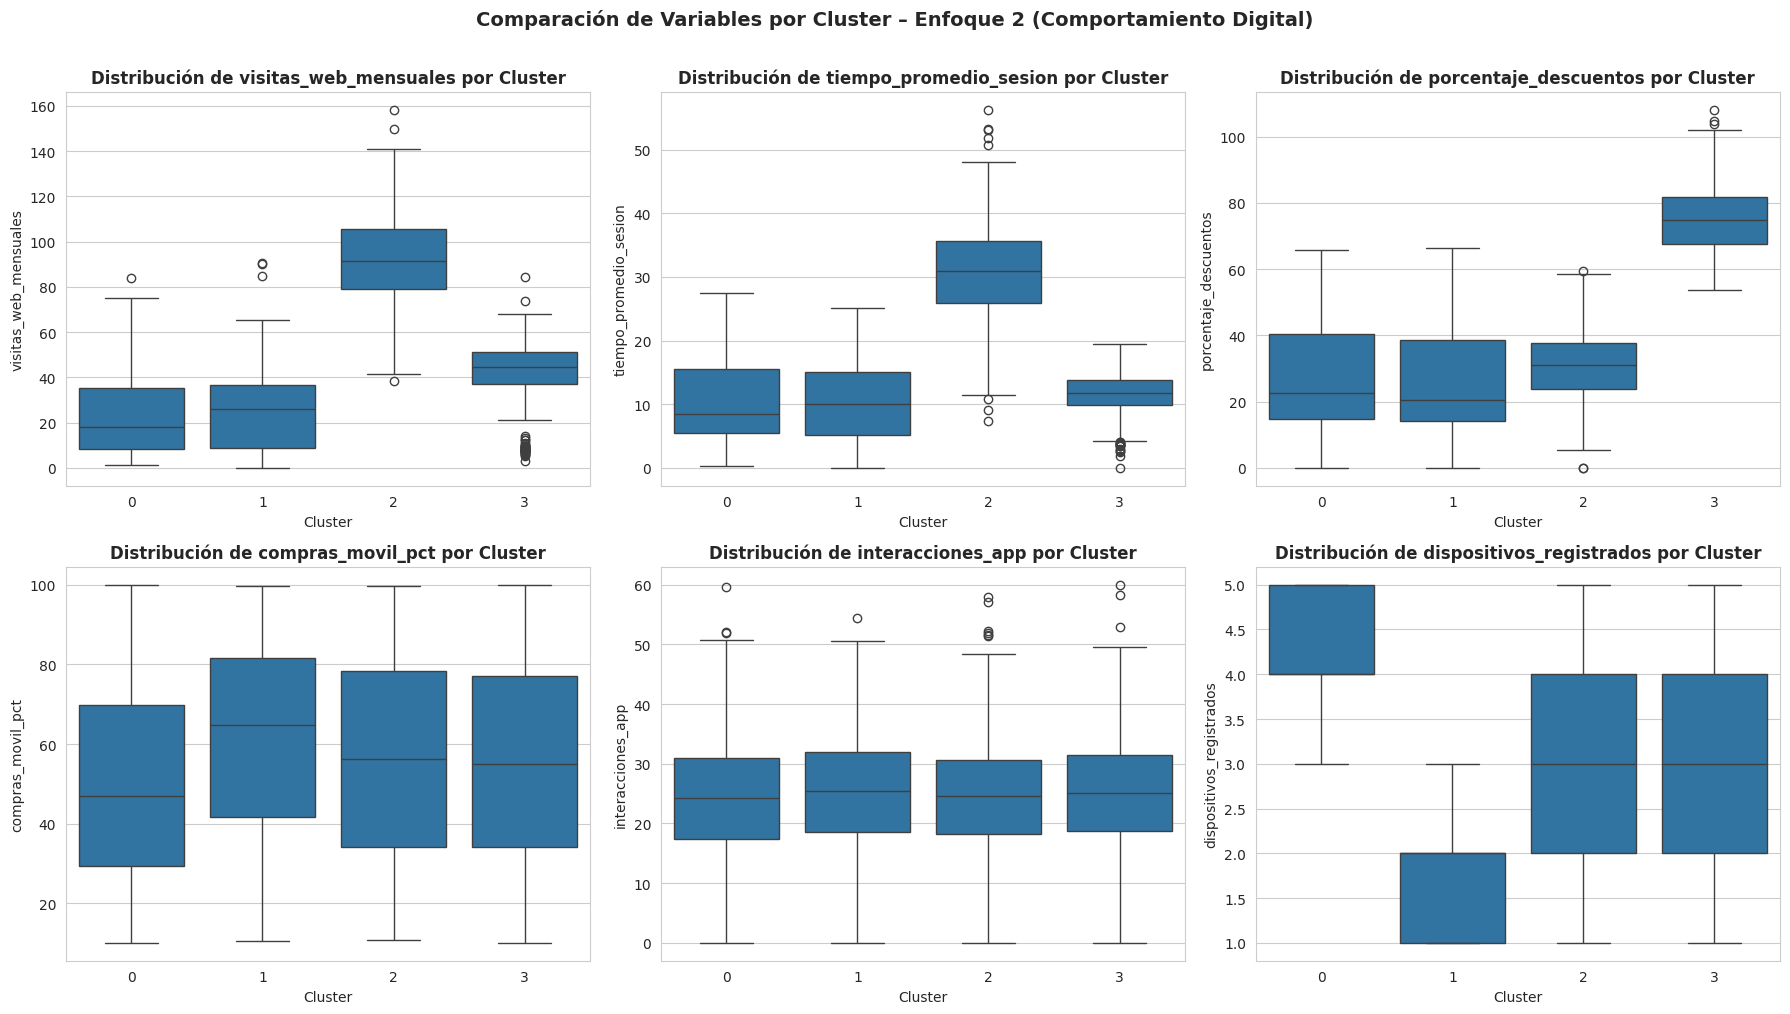

In [40]:
# Boxplots por cluster – Enfoque 2
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, vars_enfoque2):
    sns.boxplot(
        data=df,
        x='cluster_e2',
        y=col,
        ax=ax,
        
    )
    ax.set_title(f'Distribución de {col} por Cluster', fontsize=12, fontweight='bold')
    ax.set_xlabel('Cluster', fontsize=10)
    ax.set_ylabel(col, fontsize=10)

fig.suptitle(
    'Comparación de Variables por Cluster – Enfoque 2 (Comportamiento Digital)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


Varianza explicada por PC1: 30.95%
Varianza explicada por PC2: 17.15%
Varianza total explicada:   48.10%


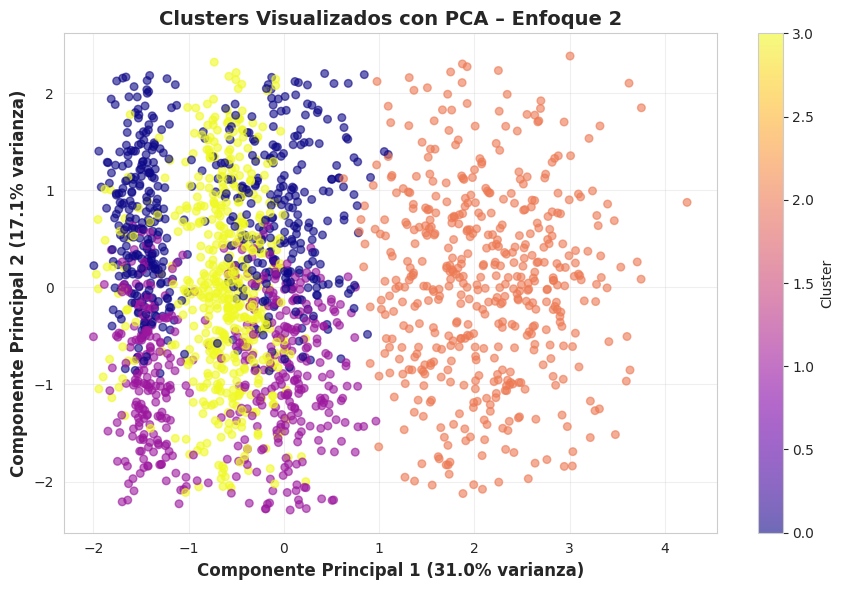

In [41]:
# Visualización PCA – Enfoque 2
pca2 = PCA(n_components=2)
X2_pca = pca2.fit_transform(X2_scaled)

varianza_e2 = pca2.explained_variance_ratio_
print(f'Varianza explicada por PC1: {varianza_e2[0]:.2%}')
print(f'Varianza explicada por PC2: {varianza_e2[1]:.2%}')
print(f'Varianza total explicada:   {sum(varianza_e2):.2%}')

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X2_pca[:, 0],
    X2_pca[:, 1],
    c=clusters2,
    cmap='plasma',
    alpha=0.6,
    s=30
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(
    f'Componente Principal 1 ({varianza_e2[0]:.1%} varianza)',
    fontsize=12, fontweight='bold'
)
plt.ylabel(
    f'Componente Principal 2 ({varianza_e2[1]:.1%} varianza)',
    fontsize=12, fontweight='bold'
)
plt.title('Clusters Visualizados con PCA – Enfoque 2',
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


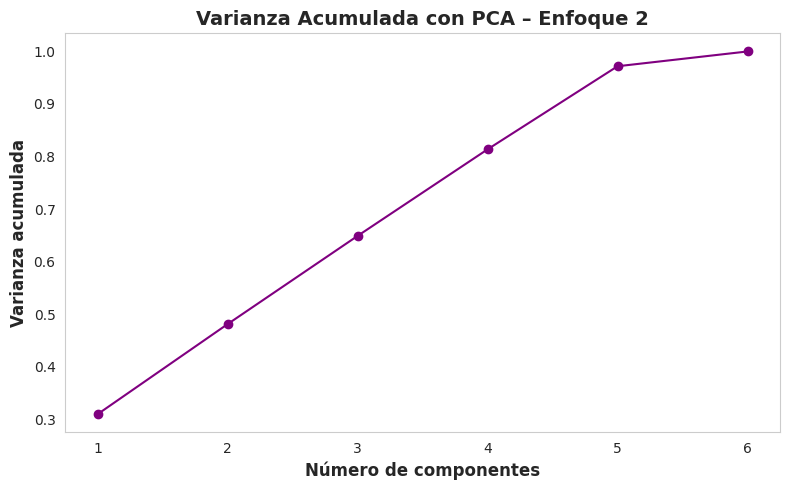

In [42]:
# Varianza acumulada PCA – Enfoque 2
pca2_full = PCA()
pca2_full.fit(X2_scaled)
varianza_acumulada2 = np.cumsum(pca2_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(varianza_acumulada2) + 1),
    varianza_acumulada2,
    marker='o',
    color='purple'
)
plt.xlabel('Número de componentes', fontsize=12, fontweight='bold')
plt.ylabel('Varianza acumulada', fontsize=12, fontweight='bold')
plt.title('Varianza Acumulada con PCA – Enfoque 2', fontsize=14, fontweight='bold')
plt.grid()
plt.tight_layout()
plt.show()


### Nombres y Descripción de Segmentos – Enfoque 2

---

#### Cluster 0: Segmento de Alta Interacción – "Usuarios Digitales Comprometidos"

**Características:** Muchas visitas web, sesiones largas, alta interacción con la app,
múltiples dispositivos registrados. Uso de descuentos moderado.  
**Perfil:** Clientes muy involucrados con la plataforma en todos sus canales. Exploran
productos, usan favoritos, comparan opciones. Alta probabilidad de conversión si se
les presenta la oferta correcta.  
**Decisión de negocio:** Personalización avanzada de contenido (recomendaciones basadas
en historial de navegación), notificaciones push inteligentes, mejoras de UX en app
para reducir fricción en el checkout.

---

#### Cluster 1: Segmento Móvil – "Compradores Móviles"

**Características:** Alto porcentaje de compras desde móvil, interacciones frecuentes
con la app, dispositivos registrados moderados-altos. Sesiones más cortas (compras
rápidas y decisivas).  
**Perfil:** Clientes que prefieren el canal móvil para comprar. Son impulsivos en
el buen sentido: si la experiencia móvil es buena, compran rápido.  
**Decisión de negocio:** Optimización del checkout móvil, campañas de marketing
por notificaciones push, diseño responsive prioritario, ofertas flash adaptadas
para móvil.

---

#### Cluster 2: Segmento Sensible al Precio – "Cazadores de Ofertas"

**Características:** Alto porcentaje de descuentos utilizado, visitas web moderadas,
sesiones de duración media (comparando precios). Menor interacción con la app.  
**Perfil:** Clientes motivados principalmente por el precio. Visitan la plataforma
principalmente cuando hay promociones. Sin descuento, la conversión es baja.  
**Decisión de negocio:** Comunicar activamente las ofertas y cupones, crear
programas de descuento progresivo para fidelizarlos, evaluar el margen que dejan
para no sacrificar rentabilidad.

---

#### Cluster 3: Segmento de Baja Interacción – "Compradores Tradicionales"

**Características:** Pocas visitas web, sesiones cortas, baja interacción con la app,
preferencia por desktop o sin preferencia digital definida. Uso mínimo de descuentos.  
**Perfil:** Clientes que utilizan la plataforma de forma utilitaria: entran, buscan
lo que necesitan y compran. No exploran, no interactúan con la app y no dependen
de descuentos.  
**Decisión de negocio:** Emails directos con productos relevantes a su historial,
simplificación del proceso de compra, minimizar distracciones en el funnel.

---

### 4.3 Comparación entre Ambos Enfoques


In [43]:
# Tabla cruzada: distribución de clientes entre segmentos de ambos enfoques
tabla_cruzada = pd.crosstab(
    df['cluster_e1'],
    df['cluster_e2'],
    rownames=['Cluster Enfoque 1 (Monetario)'],
    colnames=['Cluster Enfoque 2 (Digital)']
)
print('Tabla cruzada de clientes entre ambos enfoques:')
tabla_cruzada


Tabla cruzada de clientes entre ambos enfoques:


Cluster Enfoque 2 (Digital),0,1,2,3
Cluster Enfoque 1 (Monetario),,,,
0,240,259,1,0
1,15,11,0,465
2,35,31,409,13
3,237,185,68,31


### Análisis Comparativo entre Enfoques

#### ¿Qué información aporta cada segmentación?

| Dimensión | Enfoque 1 (Monetario y Lealtad) | Enfoque 2 (Comportamiento Digital) |
|---|---|---|
| **Pregunta que responde** | ¿Cuánto vale este cliente para la empresa y qué tan fiel es? | ¿Cómo interactúa este cliente con la plataforma digital? |
| **KPIs clave** | Gasto, frecuencia, tasa de recompra, antigüedad | Visitas, tiempo de sesión, uso de app, canal preferido |
| **Uso principal** | Priorización de recursos, programas de fidelización, retención | UX, marketing digital, personalización de canales |
| **Decisiones de negocio** | Presupuesto de atención al cliente, descuentos exclusivos VIP | Inversión en app vs. web, estrategia de notificaciones, pricing |

#### ¿Por qué los clusters son diferentes entre enfoques?

Un cliente puede ser **"Premium Fiel"** en el Enfoque 1 (alto gasto, alta lealtad) pero
**"Comprador Tradicional"** en el Enfoque 2 (pocas visitas web, baja interacción con la app),
lo que indicaría que es un cliente valioso que compra decisivamente sin necesitar explorar.
Otro cliente puede ser **"Usuario Digital Comprometido"** (muchas visitas, alta interacción app)
pero pertenecer al segmento de **"Clientes Nuevos"** en el Enfoque 1 (aún no convierte toda
esa interacción en compras).

Esto revela que los dos modelos son **complementarios**: el Enfoque 1 identifica quién
genera más valor económico; el Enfoque 2 explica *cómo* llegar a cada tipo de cliente
en su canal preferido.

#### ¿Qué decisiones de negocio se derivan de cada segmentación?

**Del Enfoque 1:**
- Asignar recursos de atención prioritaria a los Clientes Premium Fieles.
- Diseñar campañas de reactivación específicas para los Clientes Dormidos.
- Invertir en *onboarding* para convertir Clientes Nuevos en Regulares.

**Del Enfoque 2:**
- Priorizar la inversión en mejoras de la app para los Usuarios Digitales Comprometidos.
- Crear campañas de notificación push para los Compradores Mobiles.
- Diseñar estrategias de descuento sostenible para los Cazadores de Ofertas,
  buscando aumentar su frecuencia sin erosionar el margen.

**Usando ambos modelos juntos:**
- Cruzar ambos segmentos permite diseñar estrategias hiperpersonalizadas. Por ejemplo:
  un cliente que es *Premium Fiel* Y *Comprador móvil* debería recibir ofertas VIP exclusivamente
  por notificaciones push en su app, no por email.


---
## Pregunta de Reflexión


> *¿Por qué dos modelos de segmentación construidos sobre conjuntos de variables diferentes
> pueden producir agrupaciones distintas para un mismo cliente? ¿Qué ventajas tiene analizar
> a los clientes desde múltiples perspectivas en lugar de utilizar un único modelo?*

---

### Respuesta

#### ¿Por qué un mismo cliente puede pertenecer a segmentos distintos?

Un modelo de clustering no describe a un cliente de forma absoluta: lo ubica en relación
con los demás clientes, **dentro del espacio de variables que se le entrega**. Al cambiar
las variables, cambia el espacio de representación y, por tanto, cambia la noción de
"similitud" entre clientes.

Matemáticamente, K-Means minimiza la suma de distancias euclidianas al cuadrado. Si en
el Enfoque 1 las dimensiones son `{ingreso, gasto, frecuencia, ...}` y en el Enfoque 2
son `{visitas_web, tiempo_sesion, descuentos, ...}`, el algoritmo está midiendo distancias
en **espacios vectoriales completamente distintos**.

Un ejemplo concreto: el cliente A puede tener:
- **Enfoque 1:** alto gasto, alta lealtad → cluster "Premium"
- **Enfoque 2:** pocas visitas, baja interacción app → cluster "Comprador Tradicional"

Este cliente gasta mucho pero de forma directa y sin explorar: es valioso pero no
"digitalmente comprometido". Ambas clasificaciones son correctas y complementarias.

#### ¿Qué ventajas tiene el enfoque multi-perspectiva?

1. **Evita la simplificación excesiva.** Un único modelo fuerza a representar todas las
   dimensiones del cliente en una sola segmentación, lo que puede crear grupos heterogéneos
   que mezclan perfiles incompatibles.

2. **Permite estrategias más específicas.** Si se sabe que un cliente es Premium (Enfoque 1)
   y Comprador móvil (Enfoque 2), la estrategia óptima es diferente a la de un cliente Premium
   que es Comprador Tradicional.

3. **Reduce el riesgo de la dimensionalidad.** Con muchas variables, K-Means
   pierde efectividad porque las distancias euclidianas se vuelven menos discriminantes en
   espacios de alta dimensión. Usar subconjuntos temáticos mantiene dimensionalidades manejables.

4. **Facilita la acción en distintas áreas de la empresa.** El equipo de marketing digital
   usa el Enfoque 2; el equipo de ventas y fidelización usa el Enfoque 1. Cada área habla
   el idioma de sus propias métricas.

5. **Aumenta la robustez del conocimiento del cliente.** Si ambos modelos convergen en
   colocar a un cliente en segmentos similares, hay mayor confianza en ese perfil.
   Si divergen, se abre una oportunidad de análisis más profundo.

**En conclusión:** la segmentación múltiple no es redundancia, es **triangulación**.
Una empresa no debería tratar de entender a sus clientes con una única segmentación. Cada perspectiva muestra
una faceta del cliente que las otras no pueden capturar completamente.


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=551bfdcb-8db5-42a6-b14c-7c85ddebaab8' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>